pmcx version: 0.6.2
GPU info: [{'name': 'NVIDIA GeForce RTX 4060 Laptop GPU', 'id': 1, 'devcount': 1, 'major': 8, 'minor': 9, 'globalmem': 8585216000, 'constmem': 65536, 'sharedmem': 49152, 'regcount': 65536, 'clock': 1890000, 'sm': 24, 'core': 3072, 'autoblock': 64, 'autothread': 98304, 'maxgate': 0}]
target hist shape: (32, 32, 227), file: data\50mm_60d_foam\hist_5us_1e+06_38.5deg_obj.mat
IRF hist shape:    (32, 32, 227), file: data\IRF.mat
using MATLAB pixel y,x = (16, 16), bins = 227
PMCX source position: [51, 51, 1], source direction: [0.0, 0.0, 1.0]
PMCX dref output pixel [x,y,z] = (51, 51, 21) on outgoing +z face
target: sum=65240, max=1469, argmax=143, nonzero=224
IRF: sum=74286, max=22572, argmax=118, nonzero=224
nphoton: 1e+07
tstart: 0
tstep: 5.5e-11
tend: 1.2485e-08
maxdetphoton: 0
isreflect: 0
autopilot: 1
unitinmm: 2.5
issaveref: 1
mua=0.005, mus=1.4, shift=0.000, raw_sum=3.78e+05, obj=26.7478
nphoton: 1e+07
tstart: 0
tstep: 5.5e-11
tend: 1.2485e-08
maxdetphoton: 0
isrefl

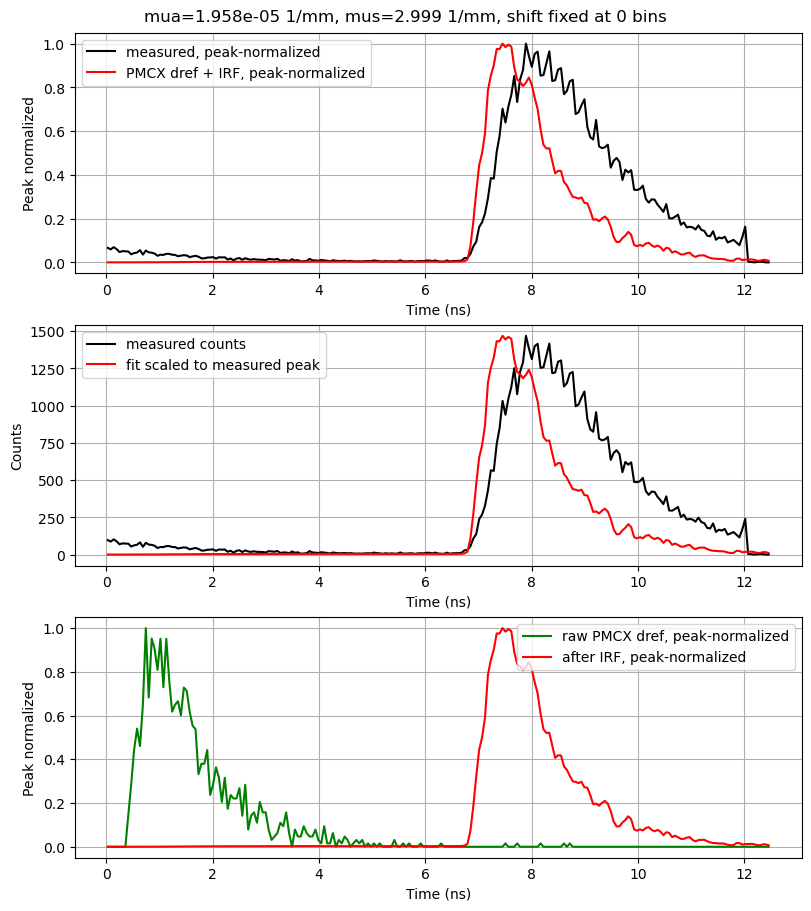

In [17]:
from pathlib import Path
from types import SimpleNamespace
import json
import math

import h5py
import numpy as np
import pmcx
import scipy.io
import scipy.optimize
import matplotlib.pyplot as plt

# ============================================================
# User configuration
# ============================================================
args = SimpleNamespace(
    target=Path('data/50mm_60d_foam/hist_5us_1e+06_38.5deg_obj.mat'),
    irf=Path('data/IRF.mat'),
    pixel_yx=(16, 16),              # MATLAB 1-based: hist(y,x,t)

    sample_size_mm=(250.0, 250.0, 50.0),
    voxel_size_mm=2.5,              # 250x250x50 mm -> 100x100x20 tissue voxels + 1 background layer each side
    n=1.48,
    g=0.90,
    time_bin_s=55e-12,

    nphoton=1e7,
    gpuid=1,
    seed=1648335518,

    # Fit mua and mus directly because this notebook is fit_pmcx_mua_mus.ipynb.
    # Units: mua, mus are both 1/mm.
    initial_mua=0.005,
    initial_mus=1.4,
    bounds_mua=(1e-5, 0.20),
    bounds_mus=(0.01, 3.0),

    fit_shift=False,               # Do not fit time shift; use shift = 0.
    shift_bounds=(0.0, 0.0),
    maxiter=80,

    # If True, the final count curve uses linear least squares scale+background.
    # Default False avoids the previous bug where scale became 0 and the curve became a flat line.
    fit_display_background=False,

    output_prefix=Path('fit_pmcx_mua_mus_result'),
)

print('pmcx version:', getattr(pmcx, '__version__', 'unknown'))
print('GPU info:', pmcx.gpuinfo())

# ============================================================
# MATLAB histogram loading
# ============================================================
def load_mat_hist(path: Path, variable: str = 'hist') -> np.ndarray:
    """Read MATLAB v7/v7.2 or v7.3 .mat hist accurately in Python."""
    try:
        mat = scipy.io.loadmat(path, squeeze_me=False, struct_as_record=False)
        if variable not in mat:
            keys = sorted(k for k in mat if not k.startswith('__'))
            raise KeyError(f'{variable!r} not found in {path}. Available variables: {keys}')
        arr = np.asarray(mat[variable], dtype=np.float64)
    except NotImplementedError:
        with h5py.File(path, 'r') as f:
            if variable not in f:
                raise KeyError(f'{variable!r} not found in {path}. Available variables: {list(f.keys())}')
            arr = np.asarray(f[variable], dtype=np.float64)
        arr = np.transpose(arr)

    if arr.ndim != 3:
        raise ValueError(f'{path}::{variable} must be 3-D, got {arr.shape}')
    if arr.shape[0] == 32 and arr.shape[1] == 32:
        return arr
    if arr.shape[-2:] == (32, 32):
        return np.transpose(arr, (1, 2, 0))
    raise ValueError(f'{path}::{variable} has unexpected shape {arr.shape}; expected 32x32xT')


def pixel_curve_1based(hist: np.ndarray, y: int, x: int) -> np.ndarray:
    curve = np.asarray(hist[y - 1, x - 1, :], dtype=np.float64).reshape(-1).copy()
    curve[~np.isfinite(curve)] = 0
    curve[curve < 0] = 0
    return curve


def normalize_area(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=np.float64).reshape(-1).copy()
    y[~np.isfinite(y)] = 0
    y[y < 0] = 0
    s = float(y.sum())
    return y / s if s > 0 else y


def normalize_peak(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=np.float64).reshape(-1).copy()
    y[~np.isfinite(y)] = 0
    y[y < 0] = 0
    m = float(y.max()) if y.size else 0.0
    return y / m if m > 0 else y


def shift_curve(y: np.ndarray, shift_bins: float) -> np.ndarray:
    x = np.arange(y.size, dtype=np.float64)
    return np.interp(x - shift_bins, x, y, left=0.0, right=0.0)


def peak_info(name, y):
    y = np.asarray(y)
    print(f'{name}: sum={y.sum():.6g}, max={y.max():.6g}, argmax={int(np.argmax(y))}, nonzero={np.count_nonzero(y)}')

# ============================================================
# PMCX forward model using issaveref/dref
# ============================================================
def make_padded_volume(sample_size_mm, voxel_size_mm):
    sample_vox = np.rint(np.asarray(sample_size_mm, dtype=np.float64) / voxel_size_mm).astype(int)
    if np.any(sample_vox <= 0):
        raise ValueError(f'Invalid sample voxel size: {sample_vox}')
    if np.any(np.abs(sample_vox * voxel_size_mm - np.asarray(sample_size_mm)) > 1e-9):
        raise ValueError('sample_size_mm must be exactly divisible by voxel_size_mm.')

    vol = np.zeros(tuple((sample_vox + 2).tolist()), dtype=np.uint8)
    vol[1:-1, 1:-1, 1:-1] = 1
    return vol, sample_vox


def make_base_cfg(args, n_bins):
    vol, sample_vox = make_padded_volume(args.sample_size_mm, args.voxel_size_mm)

    # Padded volume layout:
    # z=0 background before the slab, z=1..Nz tissue slab, z=Nz+1 output-side background.
    center_x = int(sample_vox[0] // 2 + 1)
    center_y = int(sample_vox[1] // 2 + 1)
    source_z = 1
    bottom_bg_z = int(sample_vox[2] + 1)

    cfg = {
        'nphoton': int(args.nphoton),
        'vol': vol,
        'unitinmm': float(args.voxel_size_mm),
        'srcpos': [center_x, center_y, source_z],
        'srcdir': [0.0, 0.0, 1.0],
        'prop': np.asarray([[0.0, 0.0, 1.0, 1.0], [args.initial_mua, args.initial_mus, args.g, args.n]], dtype=np.float32),
        'tstart': 0.0,
        'tend': float(n_bins * args.time_bin_s),
        'tstep': float(args.time_bin_s),
        'isreflect': 0,
        'issaveref': 1,
        'bc': 'aaaaaa',
        'gpuid': int(args.gpuid),
        'autopilot': 1,
        'maxdetphoton': 0,
        'seed': int(args.seed),
    }
    dref_center_xyz = (center_x, center_y, bottom_bg_z)
    return cfg, dref_center_xyz


def run_pmcx_dref_center(base_cfg, dref_center_xyz, mua: float, mus: float):
    cfg = dict(base_cfg)
    cfg['prop'] = np.array(base_cfg['prop'], dtype=np.float32, copy=True)
    cfg['prop'][1, :] = [mua, mus, cfg['prop'][1, 2], cfg['prop'][1, 3]]

    res = pmcx.mcxlab(cfg)
    if 'dref' not in res:
        raise RuntimeError('PMCX result does not contain dref. Make sure issaveref=1 is supported.')

    dref = np.asarray(res['dref'], dtype=np.float64)
    if dref.ndim != 4:
        raise RuntimeError(f'Expected dref as 4-D [x,y,z,t], got shape {dref.shape}')

    cx, cy, cz = dref_center_xyz
    curve = dref[cx, cy, cz, :].reshape(-1).copy()
    curve[~np.isfinite(curve)] = 0
    curve[curve < 0] = 0

    meta = {
        'dref_sum': float(curve.sum()),
        'musp_1_per_mm': float(mus * (1.0 - cfg['prop'][1, 2])),
        'D_mm_from_mua_musp': float(1.0 / (3.0 * (mua + mus * (1.0 - cfg['prop'][1, 2])))),
    }
    return curve, meta


def causal_convolve_same_length(signal, kernel):
    """Causal TCSPC convolution: y[t] = sum_tau signal[tau] * kernel[t - tau].

    Do not use mode='same' here: 'same' center-crops the full convolution and
    shifts the IRF peak earlier by roughly half the kernel length. For histogram
    data with a shared time origin, keep the first N bins of the full causal
    convolution and normalize afterwards.
    """
    signal = normalize_area(signal)
    kernel = normalize_area(kernel)
    full = np.convolve(signal, kernel, mode='full')
    return full[:signal.size]


def convolved_model_shape(raw_dref_curve, irf_curve, shift_bins):
    model = causal_convolve_same_length(raw_dref_curve, irf_curve)
    model = shift_curve(model, shift_bins)
    return normalize_peak(model)


def scale_to_counts(model_shape, target_curve, fit_background=False):
    if fit_background:
        # Ordinary least squares, not NNLS. This avoids the old scale=0 flat-line failure mode.
        a = np.column_stack([model_shape, np.ones(model_shape.size)])
        scale, background = np.linalg.lstsq(a, target_curve, rcond=None)[0]
        fitted = scale * model_shape + background
    else:
        # Shape fit: preserve the simulated time shape. The returned curve is
        # peak-normalized, so its maximum is 1.
        scale = 1.0
        background = 0.0
        fitted = normalize_peak(model_shape)
    return fitted, float(scale), float(background)


def model_curve(base_cfg, dref_center_xyz, mua, mus, irf_curve, target_curve, shift_bins):
    raw, meta = run_pmcx_dref_center(base_cfg, dref_center_xyz, mua, mus)
    if raw.sum() <= 0:
        raise RuntimeError('Center-pixel dref curve is zero; increase nphoton or check source/face geometry.')

    model_shape = convolved_model_shape(raw, irf_curve, shift_bins)
    fitted, scale, background = scale_to_counts(model_shape, target_curve, args.fit_display_background)
    meta['scale'] = scale
    meta['background'] = background
    return fitted, raw, model_shape, meta


def unpack(z, fit_shift=True):
    mua = float(np.exp(z[0]))
    mus = float(np.exp(z[1]))
    shift = float(z[2]) if fit_shift else 0.0
    return mua, mus, shift

# ============================================================
# Load measured data
# ============================================================
target_hist = load_mat_hist(args.target)
irf_hist = load_mat_hist(args.irf)

target_curve = pixel_curve_1based(target_hist, args.pixel_yx[0], args.pixel_yx[1])
irf_curve = pixel_curve_1based(irf_hist, args.pixel_yx[0], args.pixel_yx[1])
if target_curve.size != irf_curve.size:
    raise ValueError(f'target bins {target_curve.size} != IRF bins {irf_curve.size}')

base_cfg, dref_center_xyz = make_base_cfg(args, target_curve.size)
time_axis_s = (np.arange(target_curve.size) + 0.5) * args.time_bin_s

print(f'target hist shape: {target_hist.shape}, file: {args.target}')
print(f'IRF hist shape:    {irf_hist.shape}, file: {args.irf}')
print(f'using MATLAB pixel y,x = {tuple(args.pixel_yx)}, bins = {target_curve.size}')
print(f'PMCX source position: {base_cfg["srcpos"]}, source direction: {base_cfg["srcdir"]}')
print(f'PMCX dref output pixel [x,y,z] = {dref_center_xyz} on outgoing +z face')
peak_info('target', target_curve)
peak_info('IRF', irf_curve)

# ============================================================
# Fit
# ============================================================
cache = {}

def objective(z):
    mua, mus, shift = unpack(z, args.fit_shift)
    key = tuple(np.round(z, 10))

    if not (args.bounds_mua[0] <= mua <= args.bounds_mua[1]):
        return 1e12 + 1e8 * abs(mua)
    if not (args.bounds_mus[0] <= mus <= args.bounds_mus[1]):
        return 1e12 + 1e8 * abs(mus)
    if args.fit_shift and not (args.shift_bounds[0] <= shift <= args.shift_bounds[1]):
        return 1e12 + 1e6 * abs(shift)

    try:
        if key not in cache:
            cache[key] = model_curve(base_cfg, dref_center_xyz, mua, mus, irf_curve, target_curve, shift)
        _, raw, model_shape, _ = cache[key]
    except Exception as exc:
        print(f'failed: mua={mua:.6g}, mus={mus:.6g}, shift={shift:.3f}: {exc}')
        return 1e12

    y = normalize_peak(target_curve)
    m = normalize_peak(model_shape)
    residual = m - y
    value = float(np.sum(residual * residual))
    print(f'mua={mua:.6g}, mus={mus:.6g}, shift={shift:.3f}, raw_sum={raw.sum():.3g}, obj={value:.6g}')
    return value

z0 = [math.log(args.initial_mua), math.log(args.initial_mus)]
# shift is fixed to 0 when args.fit_shift is False.
if args.fit_shift:
    z0.append(0.0)

result = scipy.optimize.minimize(
    objective,
    np.asarray(z0, dtype=np.float64),
    method='Nelder-Mead',
    options={'maxiter': args.maxiter, 'xatol': 1e-3, 'fatol': 1e-3, 'disp': True},
)

# ============================================================
# Final simulation, save, and plot
# ============================================================
mua_best, mus_best, shift_best = unpack(result.x, args.fit_shift)
fitted_best, raw_best, model_shape_best, meta_best = model_curve(
    base_cfg, dref_center_xyz, mua_best, mus_best, irf_curve, target_curve, shift_best
)

fit_result = {
    'mua_1_per_mm': float(mua_best),
    'mus_1_per_mm': float(mus_best),
    'musp_1_per_mm': meta_best['musp_1_per_mm'],
    'D_mm_from_mua_musp': meta_best['D_mm_from_mua_musp'],
    'g': float(args.g),
    'n': float(args.n),
    'time_shift_bins': float(shift_best),
    'time_shift_ns': float(shift_best * args.time_bin_s * 1e9),
    'dref_sum': meta_best['dref_sum'],
    'scale': meta_best['scale'],
    'background': meta_best['background'],
    'objective': float(result.fun),
    'optimizer_success': bool(result.success),
    'optimizer_message': str(result.message),
    'source_position_voxel': base_cfg['srcpos'],
    'dref_center_pixel_xyz': dref_center_xyz,
}

args.output_prefix.with_suffix('.json').write_text(json.dumps(fit_result, indent=2), encoding='utf-8')
np.savez(
    args.output_prefix.with_suffix('.npz'),
    target_curve=target_curve,
    irf_curve=irf_curve,
    raw_dref_curve=raw_best,
    model_shape=model_shape_best,
    fitted_curve_peak_normalized=fitted_best,
    fitted_curve_counts=fitted_best * target_curve.max(),
    time_axis_s=time_axis_s,
    fit_result_json=json.dumps(fit_result),
)

print('\nBest fit:')
print(json.dumps(fit_result, indent=2))
peak_info('raw dref best', raw_best)
peak_info('model shape best', model_shape_best)
peak_info('fitted best peak-normalized', fitted_best)
peak_info('fitted best counts', fitted_best * target_curve.max())

t_ns = time_axis_s * 1e9
fig, ax = plt.subplots(3, 1, figsize=(8, 9), constrained_layout=True)

ax[0].plot(t_ns, normalize_peak(target_curve), 'k-', label='measured, peak-normalized')
ax[0].plot(t_ns, fitted_best, 'r-', label='PMCX dref + IRF, peak-normalized')
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel('Peak normalized')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(t_ns, target_curve, 'k-', label='measured counts')
ax[1].plot(t_ns, fitted_best * target_curve.max(), 'r-', label='fit scaled to measured peak')
ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel('Counts')
ax[1].grid(True)
ax[1].legend()

ax[2].plot(t_ns, normalize_peak(raw_best), 'g-', label='raw PMCX dref, peak-normalized')
ax[2].plot(t_ns, model_shape_best, 'r-', label='after IRF, peak-normalized')
ax[2].set_xlabel('Time (ns)')
ax[2].set_ylabel('Peak normalized')
ax[2].grid(True)
ax[2].legend()

fig.suptitle(f'mua={mua_best:.4g} 1/mm, mus={mus_best:.4g} 1/mm, shift fixed at 0 bins')
fig.savefig(args.output_prefix.with_suffix('.png'), dpi=200)
plt.show()
